In [67]:
import pandas as pd

In [299]:
data=pd.read_csv('election.csv')

In [301]:
data.head(5)

,ID,State,Constituency,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Result
0,1,Andaman & Nicobar Islands,Andaman & Nicobar Islands,BISHNU PADA RAY,Bharatiya Janata Party,102182,254,102436,50.58,Won
1,2,Andaman & Nicobar Islands,Andaman & Nicobar Islands,KULDEEP RAI SHARMA,Indian National Congress,77829,211,78040,38.54,Lost
2,3,Andaman & Nicobar Islands,Andaman & Nicobar Islands,MANOJ PAUL,Andaman Nicobar Democratic Congress,8236,18,8254,4.08,Lost
3,4,Andaman & Nicobar Islands,Andaman & Nicobar Islands,D AYYAPPAN,Communist Party of India (Marxist),6009,8,6017,2.97,Lost
4,5,Andaman & Nicobar Islands,Andaman & Nicobar Islands,V.K. ABDUL AZIZ,Independent,2195,8,2203,1.09,Lost


In [303]:
data.shape

(8902, 10)

In [305]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8902 entries, 0 to 8901
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            8902 non-null   int64 
 1   State         8902 non-null   object
 2   Constituency  8902 non-null   object
 3   Candidate     8902 non-null   object
 4   Party         8902 non-null   object
 5   EVM Votes     8902 non-null   object
 6   Postal Votes  8902 non-null   object
 7   Total Votes   8902 non-null   int64 
 8   % of Votes    8902 non-null   object
 9   Result        8902 non-null   object
dtypes: int64(2), object(8)
memory usage: 695.6+ KB


In [306]:
data.isnull().any()

ID              False
State           False
Constituency    False
Candidate       False
Party           False
EVM Votes       False
Postal Votes    False
Total Votes     False
% of Votes      False
Result          False
dtype: bool

In [308]:
data.duplicated().sum()

0

In [311]:
data['Party'].nunique()

746

In [312]:
data['State'].nunique()

36

In [314]:
data['Party'].value_counts().head(10)  #Total Candidates per Party

Party
Independent                                    3920
None of the Above                               542
Bahujan Samaj Party                             488
Bharatiya Janata Party                          441
Indian National Congress                        328
Socialist Unity Centre Of India (COMMUNIST)     150
Peoples Party of India (Democratic)              79
Samajwadi Party                                  71
Communist Party of India  (Marxist)              52
All India Trinamool Congress                     48
Name: count, dtype: int64

In [315]:
data['Result'].value_counts()

Result
Lost    8359
Won      543
Name: count, dtype: int64

# EDA

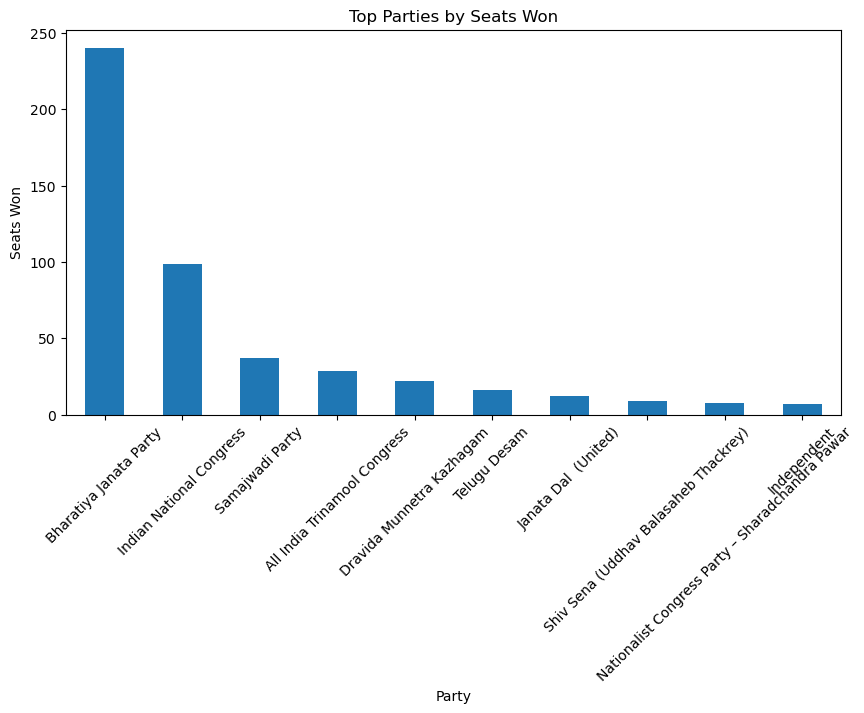

In [323]:
winners = data[data['Result'] == 'Won']

party_wins = winners['Party'].value_counts().head(10)

party_wins.plot(kind='bar', figsize=(10,5))
plt.title("Top Parties by Seats Won")
plt.xlabel("Party")
plt.ylabel("Seats Won")
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Count Plot')

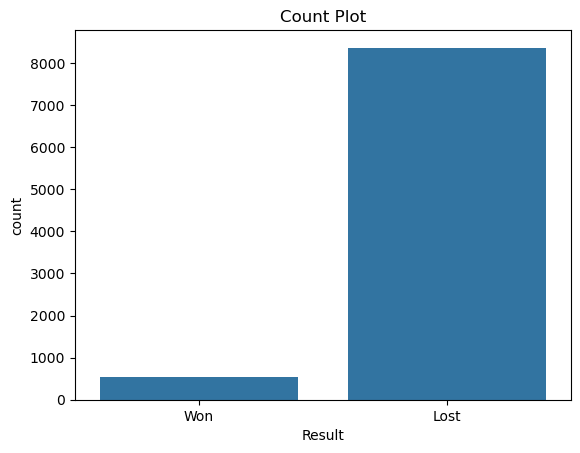

In [340]:
sns.countplot(x="Result", data = data) 
plt.title("Count Plot")

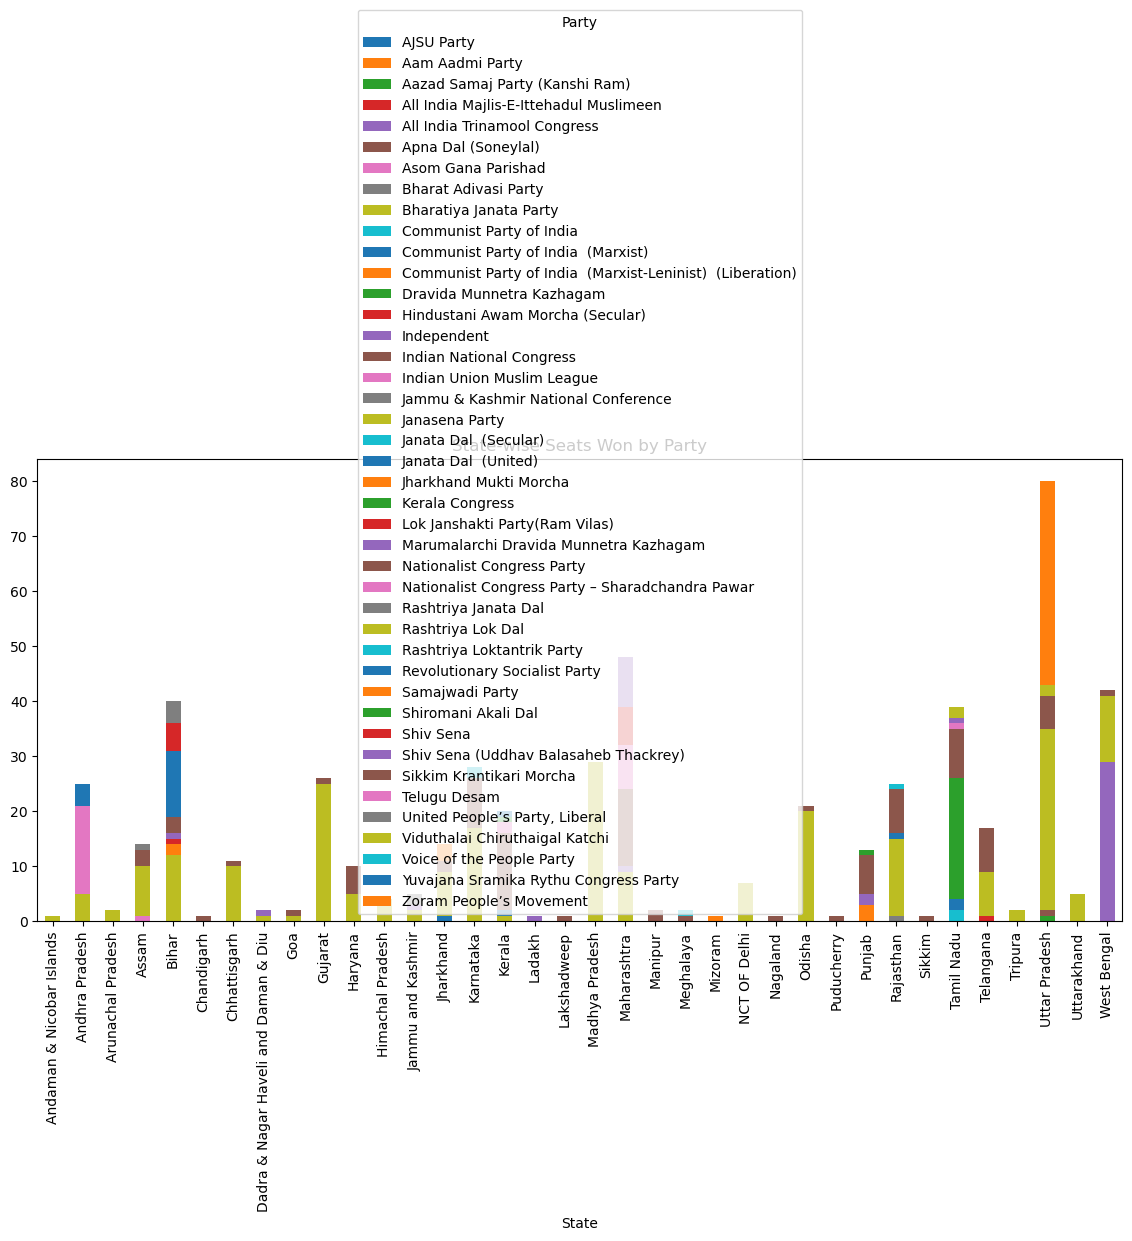

In [325]:
pd.crosstab(winners['State'], winners['Party']).plot(
    kind='bar', stacked=True, figsize=(14,6)
)
plt.title("State-wise Seats Won by Party")
plt.show()

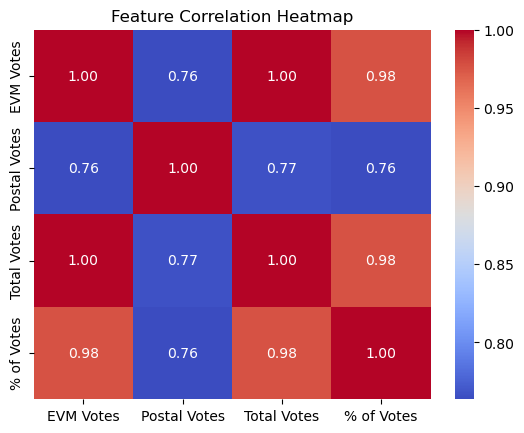

In [333]:
cols = ['EVM Votes', 'Postal Votes', '% of Votes']

for col in cols:
    data[col] = data[col].astype(str).str.replace(',', '').str.strip()
    data[col] = pd.to_numeric(data[col], errors='coerce')

import seaborn as sns
import matplotlib.pyplot as plt

corr = data[['EVM Votes','Postal Votes','Total Votes','% of Votes']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

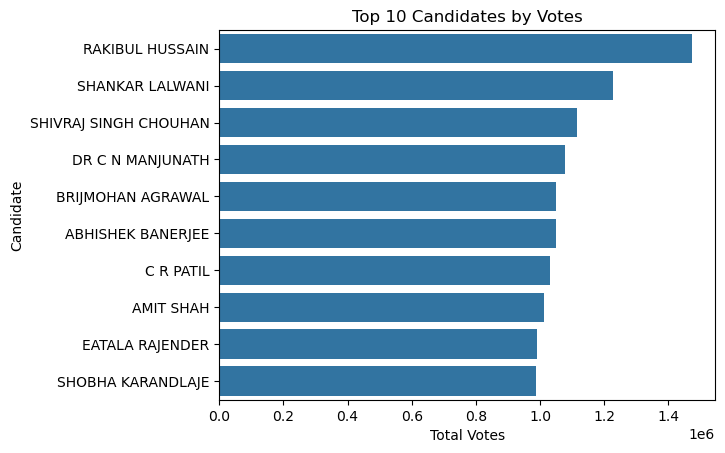

In [335]:
top = data.nlargest(10, 'Total Votes')

sns.barplot(x='Total Votes', y='Candidate', data=top)
plt.title("Top 10 Candidates by Votes")
plt.show()

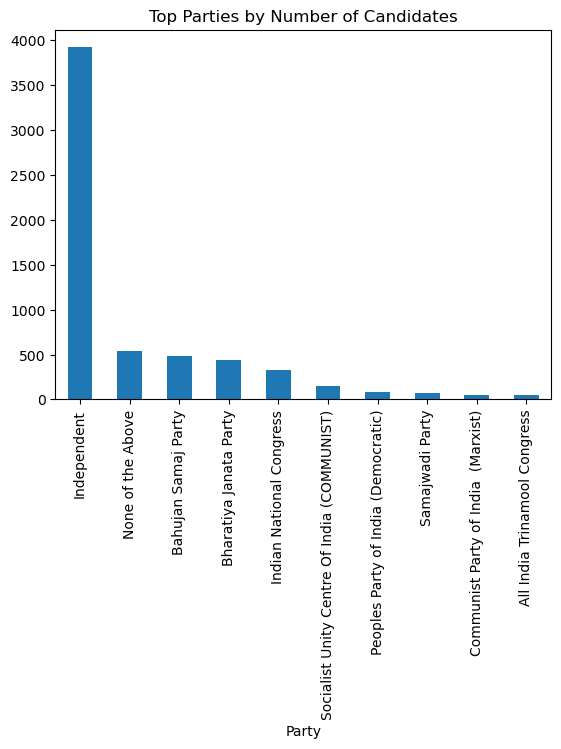

In [336]:
data['Party'].value_counts().head(10).plot(kind='bar')
plt.title("Top Parties by Number of Candidates")
plt.show()

# DATA PREPROCESSING

In [354]:
from sklearn.preprocessing import LabelEncoder
clmn=['State','Constituency','Candidate','Party','Result']
label_encoder= LabelEncoder()
for column in clmn:
    data[column]=label_encoder.fit_transform(data[column])
print(data.head(10))

   ID  State  Constituency  Candidate  Party  EVM Votes  Postal Votes  \
0   1      0            30       1374    158   102182.0         254.0   
1   2      0            30       3688    289    77829.0         211.0   
2   3      0            30       4146     83     8236.0          18.0   
3   4      0            30       1663    227     6009.0           8.0   
4   5      0            30       7708    282     2195.0           8.0   
5   6      0            30       3167     55      911.0           3.0   
6   7      0            30       2040    121      714.0           5.0   
7   8      0            30       6111    282      539.0           3.0   
8   9      0            30       3189    282      506.0           1.0   
9  10      0            30       7673    282      378.0           2.0   

   Total Votes  % of Votes  Result  
0       102436       50.58       1  
1        78040       38.54       0  
2         8254        4.08       0  
3         6017        2.97       0  
4         2

In [356]:
from sklearn.preprocessing import StandardScaler
numerical_columns=['EVM Votes','Postal Votes','Total Votes','% of Votes']
data[numerical_columns] = data[numerical_columns].apply(pd.to_numeric, errors='coerce')
data[numerical_columns] = data[numerical_columns].fillna(data[numerical_columns].mean())
scaler=StandardScaler()
data[numerical_columns]=scaler.fit_transform(data[numerical_columns])
print(data.head())

   ID  State  Constituency  Candidate  Party  EVM Votes  Postal Votes  \
0   1      0            30       1374    158   0.168278     -0.146707   
1   2      0            30       3688    289   0.032121     -0.178918   
2   3      0            30       4146     83  -0.356972     -0.323494   
3   4      0            30       1663    227  -0.369423     -0.330985   
4   5      0            30       7708    282  -0.390747     -0.330985   

   Total Votes  % of Votes  Result  
0     0.166434    3.041252       1  
1     0.030817    2.218236       0  
2    -0.357123   -0.137341       0  
3    -0.369559   -0.213217       0  
4    -0.390761   -0.341728       0  


# LOGISTIC REGRESSION

In [359]:
X = data.drop(['Result', 'Candidate', 'Constituency'], axis=1)  #dropping unrequired columns and defining the independent variable
y=data['Result']

In [361]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4,stratify=y)

In [363]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(X_train,y_train)

C:\Users\alka2\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [365]:
y_pred=LR.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


# Model Performance Of Logistic Regression

In [368]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [370]:
print("accuracy",accuracy_score(y_test,y_pred))
print("precision",precision_score(y_test,y_pred,average='micro'))
print("recall score",recall_score(y_test,y_pred,average='micro'))
print("classification report",classification_report(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test, y_pred))

accuracy 0.9769792251544076
precision 0.9769792251544076
recall score 0.9769792251544076
classification report               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1672
           1       0.79      0.84      0.82       109

    accuracy                           0.98      1781
   macro avg       0.89      0.91      0.90      1781
weighted avg       0.98      0.98      0.98      1781

confusion matrix [[1648   24]
 [  17   92]]


# DECISION TREE

In [373]:
from sklearn.tree import DecisionTreeClassifier

In [375]:
model=DecisionTreeClassifier()

In [377]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [379]:
y_pred1=model.predict(X_test)
y_pred1

array([1, 0, 0, ..., 0, 0, 0])

# Model Performance Of Decision Tree

In [382]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,roc_curve,roc_auc_score,auc,confusion_matrix

In [384]:
print("accuracy",accuracy_score(y_test,y_pred1))
print("precision",precision_score(y_test,y_pred1,average='micro'))
print("recall score",recall_score(y_test,y_pred1,average='micro'))
print("classification report",classification_report(y_test,y_pred1))

accuracy 0.9769792251544076
precision 0.9769792251544076
recall score 0.9769792251544076
classification report               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1672
           1       0.83      0.78      0.81       109

    accuracy                           0.98      1781
   macro avg       0.91      0.88      0.90      1781
weighted avg       0.98      0.98      0.98      1781



roc curve

In [387]:
from sklearn.model_selection import learning_curve

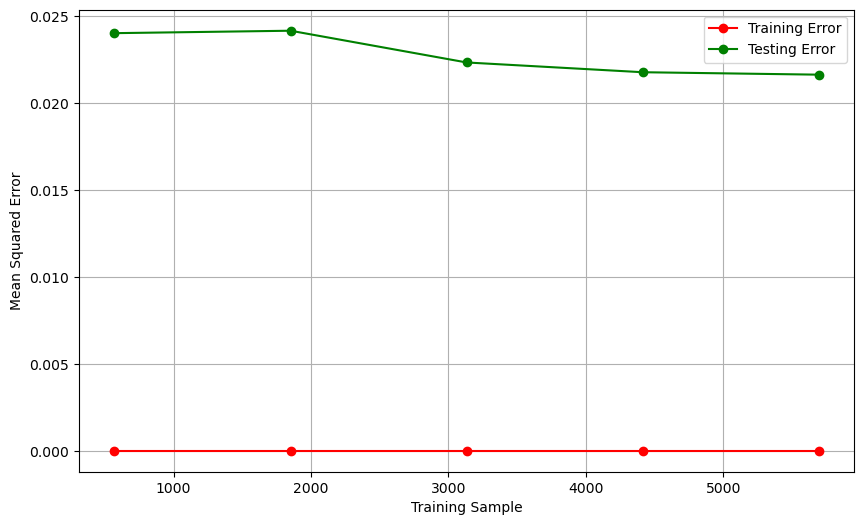

In [389]:
def plot_learning_curve(estimator, X_train, y_train, cv=None, train_sizes=np.linspace(0.1,1.0,5)):
    train_size, train_score, test_score = learning_curve(estimator, X_train, y_train, cv=cv, train_sizes=train_sizes, scoring='neg_mean_squared_error')
    train_score_mean = -np.mean(train_score, axis=1)
    test_score_mean = -np.mean(test_score, axis=1)
    plt.figure(figsize=(10,6))
    plt.plot(train_size,train_score_mean, 'o-', color='red', label ='Training Error')
    plt.plot(train_size,test_score_mean, 'o-', color='green', label ='Testing Error')
    plt.xlabel("Training Sample")
    plt.ylabel("Mean Squared Error")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

Classifier = DecisionTreeClassifier()
plot_learning_curve(Classifier, X_train, y_train, cv=5)


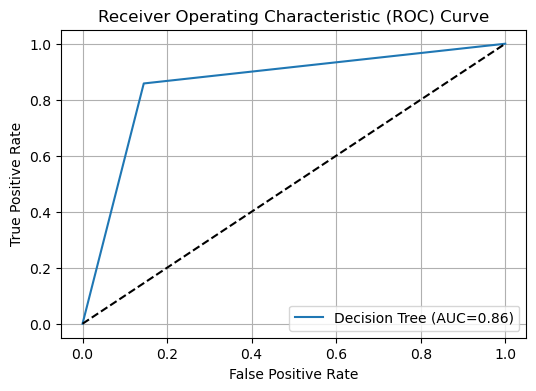

In [390]:
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, auc
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred_probability = model.predict_proba(x_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_probability[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Decision Tree (AUC=%0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Random Forest

In [394]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [396]:
from sklearn.ensemble import RandomForestClassifier

In [398]:
rf_model=RandomForestClassifier()

In [400]:
rf_model.fit(X_train,y_train)

RandomForestClassifier()

In [401]:
rf_pred=rf_model.predict(X_test)

# Model Performance Of Random Forest

In [405]:
print("accuracy",accuracy_score(y_test,rf_pred))
print("precision",precision_score(y_test,rf_pred,average='micro'))
print("recall score",recall_score(y_test,rf_pred,average='micro'))
print("classification report",classification_report(y_test,rf_pred))

accuracy 0.885
precision 0.885
recall score 0.885
classification report               precision    recall  f1-score   support

           0       0.89      0.87      0.88        97
           1       0.88      0.90      0.89       103

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



In [407]:
from sklearn.model_selection import learning_curve

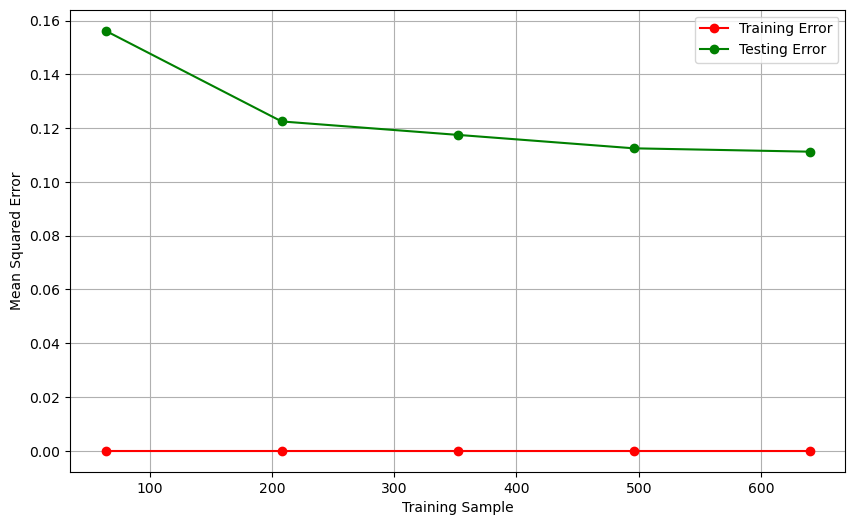

In [409]:
def plot_learning_curve(estimator, X_train, y_train, cv=None, train_sizes=np.linspace(0.1,1.0,5)):
    train_size, train_score, test_score = learning_curve(estimator, X_train, y_train, cv=cv, train_sizes=train_sizes, scoring='neg_mean_squared_error')
    train_score_mean = -np.mean(train_score, axis=1)
    test_score_mean = -np.mean(test_score, axis=1)
    plt.figure(figsize=(10,6))
    plt.plot(train_size,train_score_mean, 'o-', color='red', label ='Training Error')
    plt.plot(train_size,test_score_mean, 'o-', color='green', label ='Testing Error')
    plt.xlabel("Training Sample")
    plt.ylabel("Mean Squared Error")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

Classifier = RandomForestClassifier()
plot_learning_curve(Classifier, X_train, y_train, cv=5)
